# Base Networks Comparison Analysis

In [6]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [39]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_base_"

# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


### Check

In [40]:
# --- Verification Step: Check if lines were extended ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines:
        if n.lines.s_nom.equals(n.lines.s_nom_opt):
            print(f"Verification PASSED for '{name}' network: Line capacities were not extended (s_nom equals s_nom_opt).")
        else:
            diff_count = (n.lines.s_nom != n.lines.s_nom_opt).sum()
            print(f"Verification FAILED for '{name}' network: {diff_count} lines have different s_nom and s_nom_opt.")
    else:
        print(f"Verification NOTE for '{name}' network: No 's_nom_opt' column found; assuming lines were not extendable.")

Verification PASSED for 'windy' network: Line capacities were not extended (s_nom equals s_nom_opt).
Verification PASSED for 'notwindy' network: Line capacities were not extended (s_nom equals s_nom_opt).
Verification PASSED for 'windvariability' network: Line capacities were not extended (s_nom equals s_nom_opt).


In [53]:
# --- Fix Step: If verification fails, disable line extension on the base network ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines and not n.lines.s_nom.equals(n.lines.s_nom_opt):
        print(f"Fixing base network for '{name}'...")
        
        # Construct the path to the original base network in the 'resources' directory
        folder_name = f"germany_base_{name}"
        base_network_path = f"{home}/pypsa-eur/resources/{folder_name}/networks/base_s_{cluster}_elec_.nc"
        
        # Check if the file exists before trying to modify it
        if not os.path.exists(base_network_path):
            print(f"ERROR: Base network file not found at {base_network_path}. Skipping fix.")
            continue

        # Load the original base network
        base_n = pypsa.Network(base_network_path)
        
        # Set s_nom_extendable to False
        for component in base_n.iterate_components(["Line", "Link"]):
            if "s_nom_extendable" in component.df.columns:
                component.df["s_nom_extendable"] = False
            
        # Save the corrected network back to its original location
        base_n.export_to_netcdf(base_network_path)
        print(f"'{name}' base network at {base_network_path} has been updated to disable line extensions.")
        print("Warning: Remember to rerun solve to apply the changes!")

### Grid Congestion and Curtailment

##### Marginal Prices

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    min_prices = n.buses_t.marginal_price.loc[peak_price_time]
    print(f"Minimum marginal price across all buses at peak time: {min_prices.min():.2f} €/MWh")
    #print(loading_avg.sort_values(ascending=False).head(20))
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01, # Size buses by marginal price
        bus_colors=peak_prices,       # Color buses by marginal price
        bus_cmap='RdYlGn_r',
        line_colors=avg_loading_n,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

    return peak_prices

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_network_congestion(n, axes[i], n.name + " Network - Average Line Loading")
    print(peak_prices.describe())
    i += 1

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Load shedding

No generator carrier containing 'load' found. Plot will show zeros.
No generator carrier containing 'load' found. Plot will show zeros.
No generator carrier containing 'load' found. Plot will show zeros.


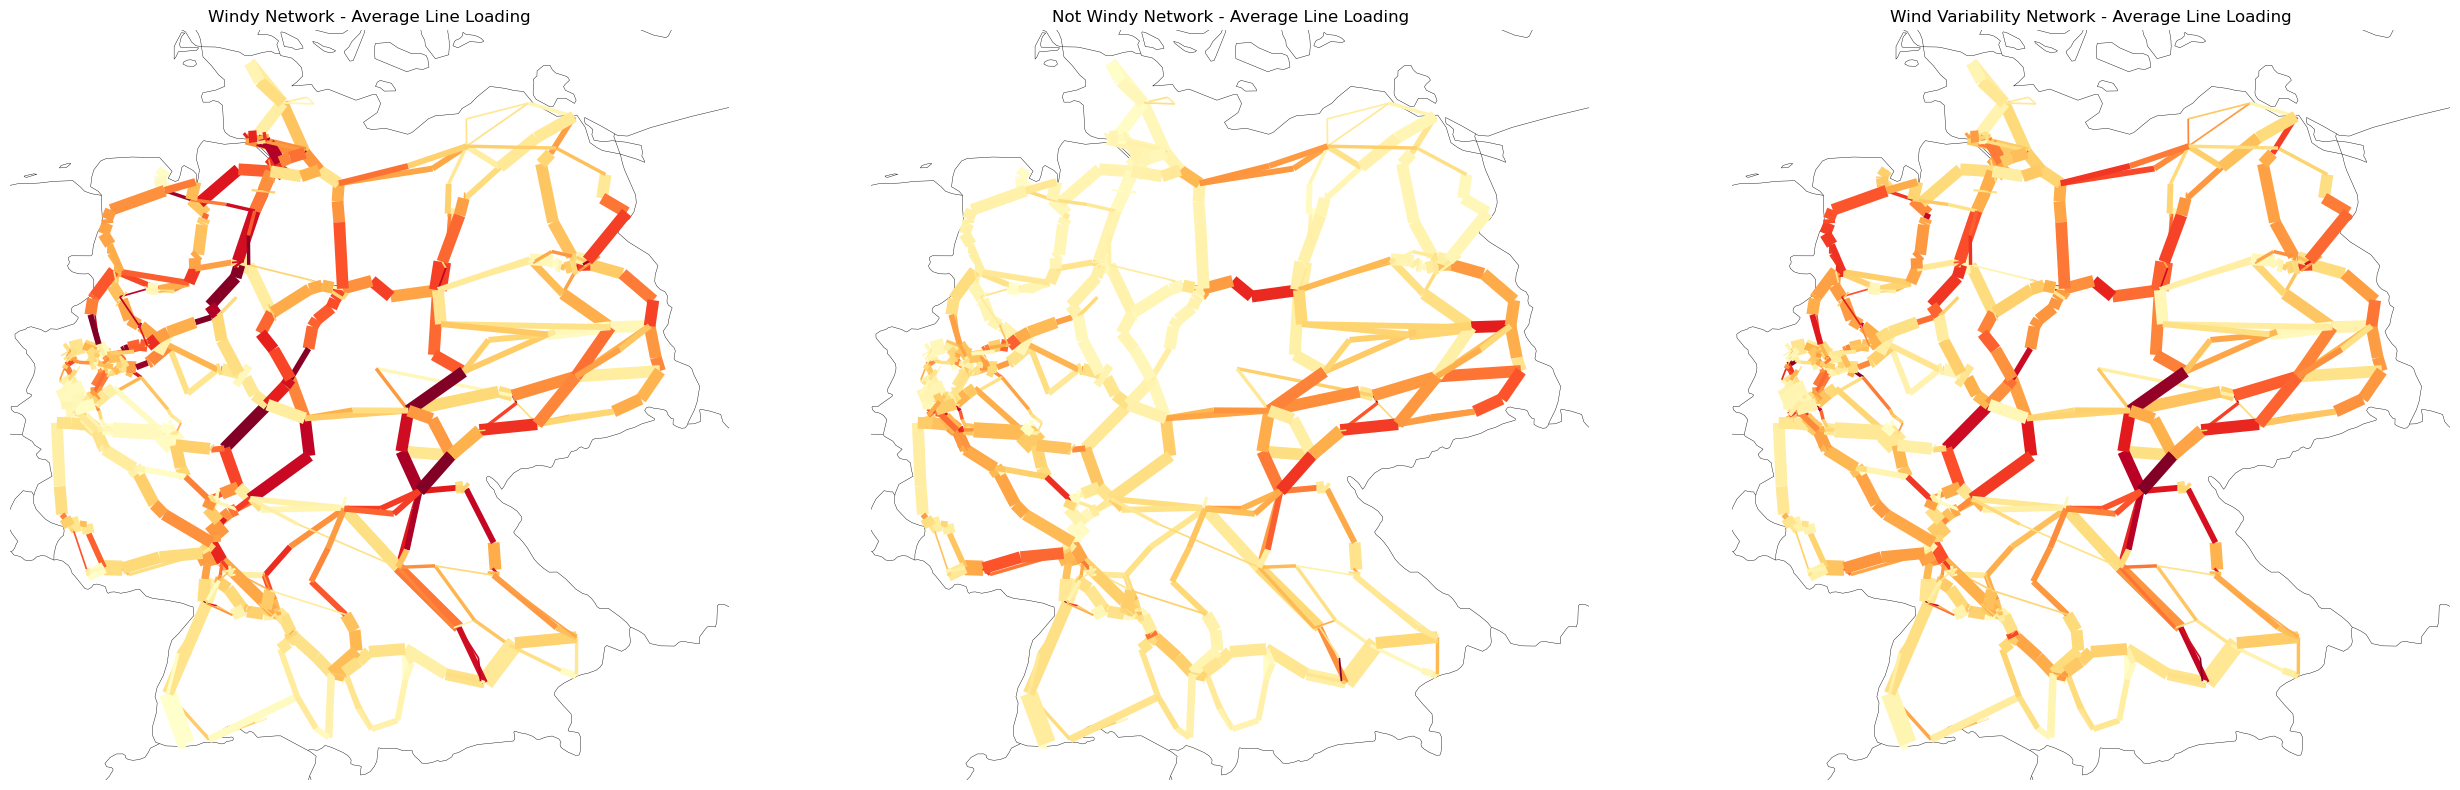

In [44]:
# --- Calculate average loading across all snapshots ---
avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        used_carriers = sorted(n.generators.loc[shed_gens, "carrier"].unique())
        print(f"Using load-related carriers: {used_carriers}")

        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )


    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]


    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        #bus_sizes=0.01, # Size buses by unmet load at worst snapshot
        bus_sizes=unmet_load_at_snapshot/5000,
        #bus_colors=unmet_load_at_snapshot,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network
plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

In [45]:
# --- Print congestion statistics ---
print("\n" + "=" * 70)
print("CONGESTION STATISTICS")
print("=" * 70)
print(f"\nWindy Network:")
print(f"  Average loading across all lines: {avg_loading_n1.mean():.2%}")
print(f"  Max average loading: {avg_loading_n1.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n1 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n1 > 0.7).sum()}")

print(f"\nNot Windy Network:")
print(f"  Average loading across all lines: {avg_loading_n2.mean():.2%}")
print(f"  Max average loading: {avg_loading_n2.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n2 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n2 > 0.7).sum()}")

print(f"\nWind Variability Network:")
print(f"  Average loading across all lines: {avg_loading_n3.mean():.2%}")
print(f"  Max average loading: {avg_loading_n3.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n3 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n3 > 0.7).sum()}")
print("=" * 70)


CONGESTION STATISTICS

Windy Network:
  Average loading across all lines: 24.09%
  Max average loading: 69.94%
  Lines with >60% avg loading: 28
  Lines with >70% avg loading: 0

Not Windy Network:
  Average loading across all lines: 15.97%
  Max average loading: 69.97%
  Lines with >60% avg loading: 6
  Lines with >70% avg loading: 0

Wind Variability Network:
  Average loading across all lines: 23.58%
  Max average loading: 69.92%
  Lines with >60% avg loading: 10
  Lines with >70% avg loading: 0


##### Offshore Wind Curtailment

In [5]:
def plot_curtailment(n, carrier, ax):
    p_available_by_carrier = (
        n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    )
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

    # Correct for any minor negative values from floating point inaccuracies.
    p_curtailed_by_carrier[p_curtailed_by_carrier < 0] = 0

    capacity = n.generators.groupby("carrier")["p_nom"].sum().at[carrier]

    p_df = pd.DataFrame(
        {
            carrier + " available": p_available_by_carrier[carrier],
            carrier + " dispatched": p_by_carrier[carrier],
            carrier + " curtailed": p_curtailed_by_carrier[carrier],
        }
    )

    p_df[carrier + " capacity"] = capacity
    p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0)
    p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax)

    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_ylim([0, p_df[carrier + " capacity"].max() * 1.1 if hasattr(p_df[carrier + " capacity"], "max") else None])
    ax.set_title(f"{n.name} - {carrier} Curtailment")

    carrier = "offwind-ac"
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_av_by = p_available.T.groupby(n.generators.carrier).sum().T
    p_disp_by = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_cur = (p_av_by - p_disp_by).clip(lower=0)

    tot_av = p_av_by[carrier].sum()
    tot_disp = p_disp_by[carrier].sum()
    tot_cur = p_cur[carrier].sum()
    
    print("=" * 70)
    print(f"Network: {n.name}")
    print(carrier, "capacity MW:", n.generators.groupby("carrier")["p_nom"].sum().get(carrier))
    print("Total available (MWh):", tot_av)
    print("Total dispatched (MWh):", tot_disp)
    print("Total curtailed (MWh):", tot_cur)
    print("Curtailed fraction:", tot_cur / tot_av if tot_av else float("nan"))
    print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])


plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

Found negative curtailment values for Windy - onwind: snapshot             carrier   
2025-10-26 00:00:00  CCGT            -0.002111
                     OCGT            -0.002420
                     biomass       -658.656206
                     coal         -2379.002579
                     geothermal     -19.100264
                                      ...     
2025-10-26 23:00:00  coal         -1569.632516
                     geothermal     -19.100075
                     lignite         -0.000371
                     oil             -0.000941
                     waste           -0.001656
Length: 192, dtype: float64
Total curtailed onwind in 'Windy' network: 499821.67 MWh
offwind-ac capacity MW: 11163.743
Total available (MWh): 236217.48034710326
Total dispatched (MWh): 24906.580774420603
Total curtailed (MWh): 211310.89957268265
Curtailed fraction: 0.8945608058395073
Found negative curtailment values for Not Windy - onwind: snapshot             carrier   
2025-04-08 00:00:00  C

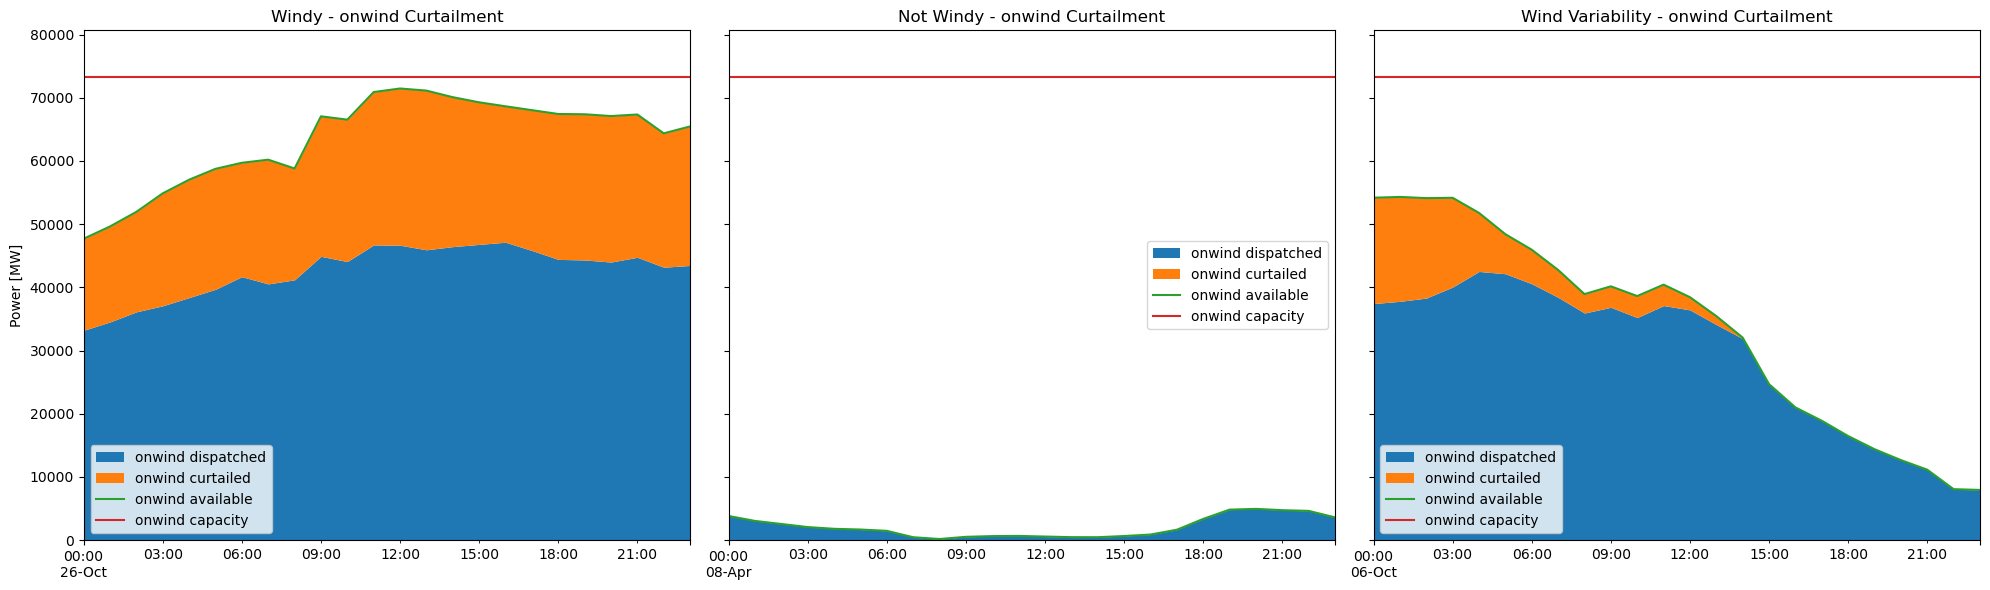

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

In [62]:
p_by_carrier = n1.generators_t.p.T.groupby(n1.generators.carrier).sum().T
print(p_by_carrier.sum())

carrier
CCGT             4.806987e-02
OCGT             5.546704e-02
biomass          1.407690e+04
coal             5.365307e+04
geothermal       4.673510e+02
lignite          8.700092e-03
offwind-ac       2.490658e+04
offwind-dc       0.000000e+00
offwind-float    0.000000e+00
oil              2.242822e-02
onwind           1.020955e+06
ror              3.950972e+04
solar            6.549729e+04
solar-hsat       0.000000e+00
waste            1.220310e+02
dtype: float64


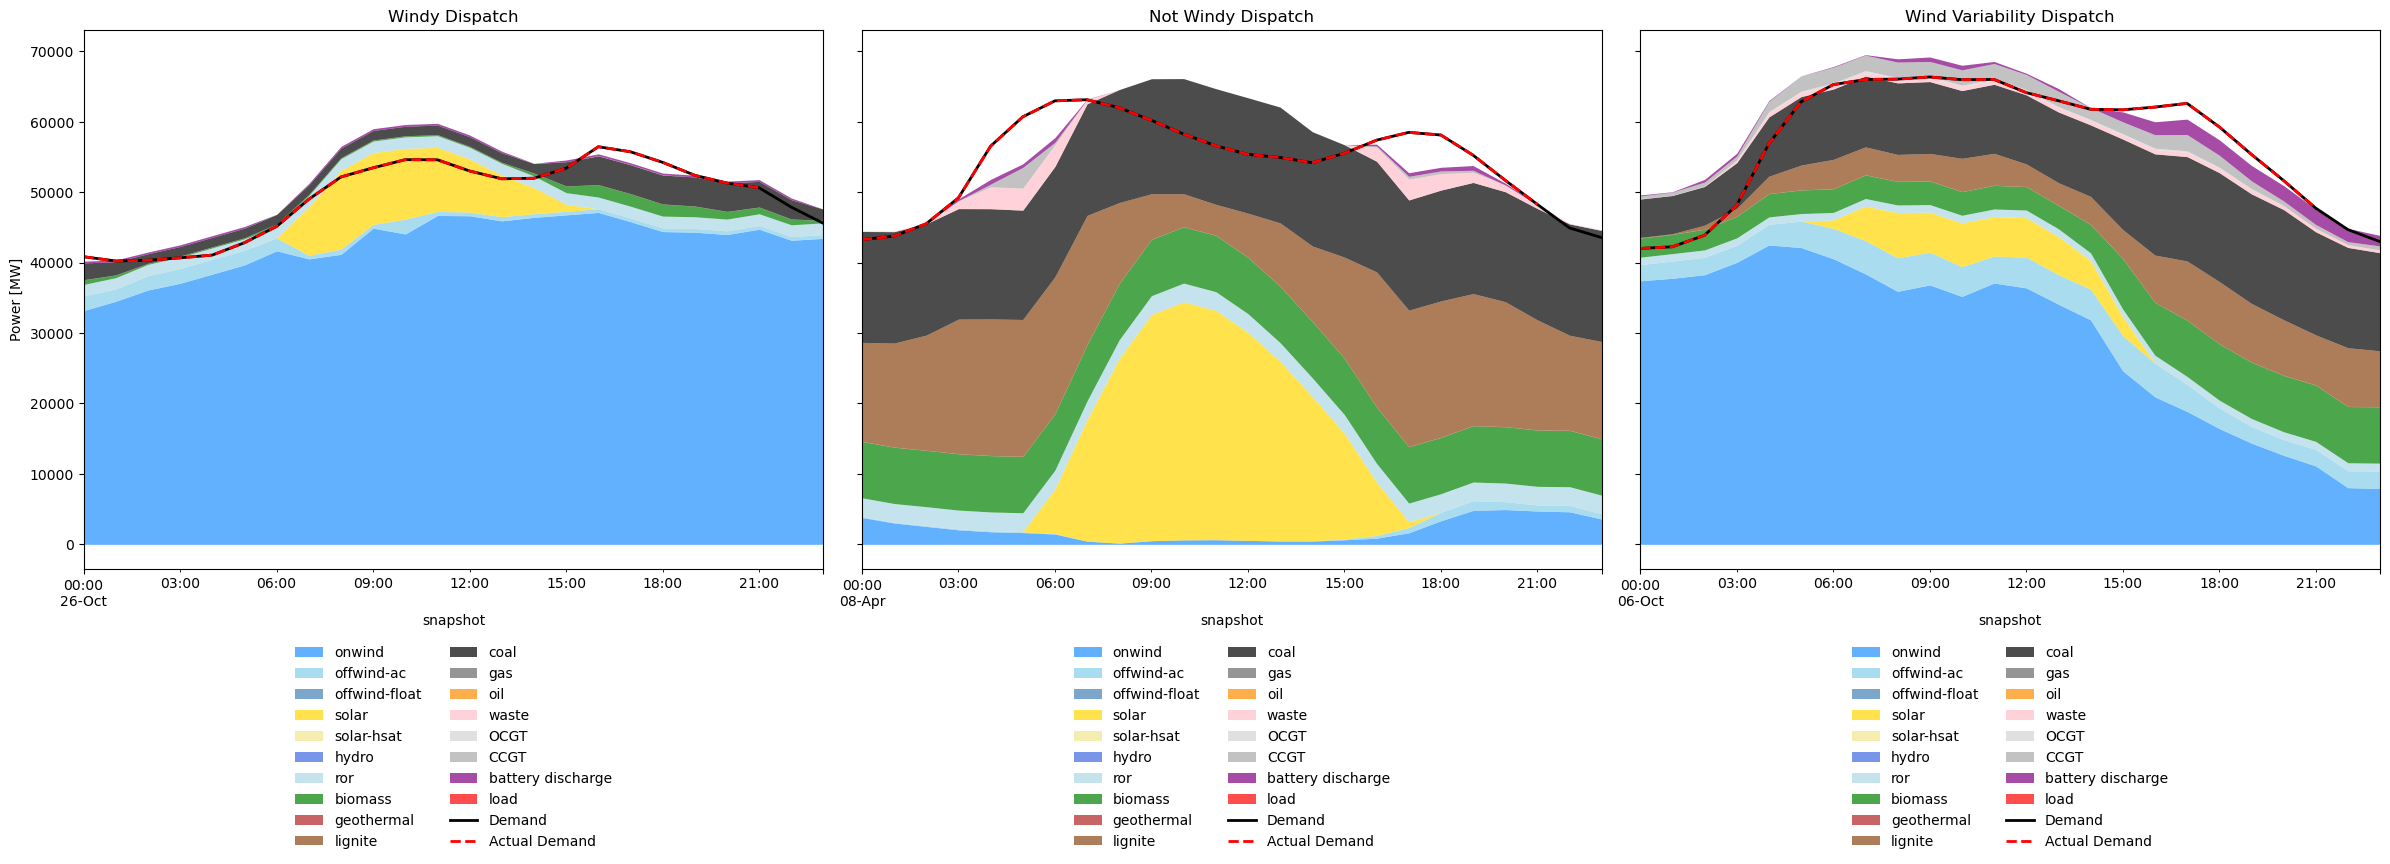

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "skyblue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "gas": "dimgray",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    "geothermal": "firebrick",
    "battery discharge": "purple",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", "offwind-float", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    # Conventional
    "lignite", "coal", "gas", "oil", "waste",
    "OCGT", "CCGT",
    # Storage
    "battery discharge",
    "load"
]


# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="black", lw=2, label="Demand")

    scenario_title = n.name
    
    real_data = pd.read_csv(f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_title.replace(' ', '_').lower()}.csv", index_col=0, parse_dates=True)
    demand_real = real_data["grid load"]
    # Use simulation snapshots as index for real data to align with simulation time axis
    demand_real = pd.Series(demand_real.values, index=n.snapshots, name="Actual Demand")
    # Shift real data by two hours
    demand_real = demand_real.shift(-2)
    demand_real.plot(ax=ax, color="red",  linestyle="--", lw=2, label="Actual Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

##### Total Energy Production by Carrier

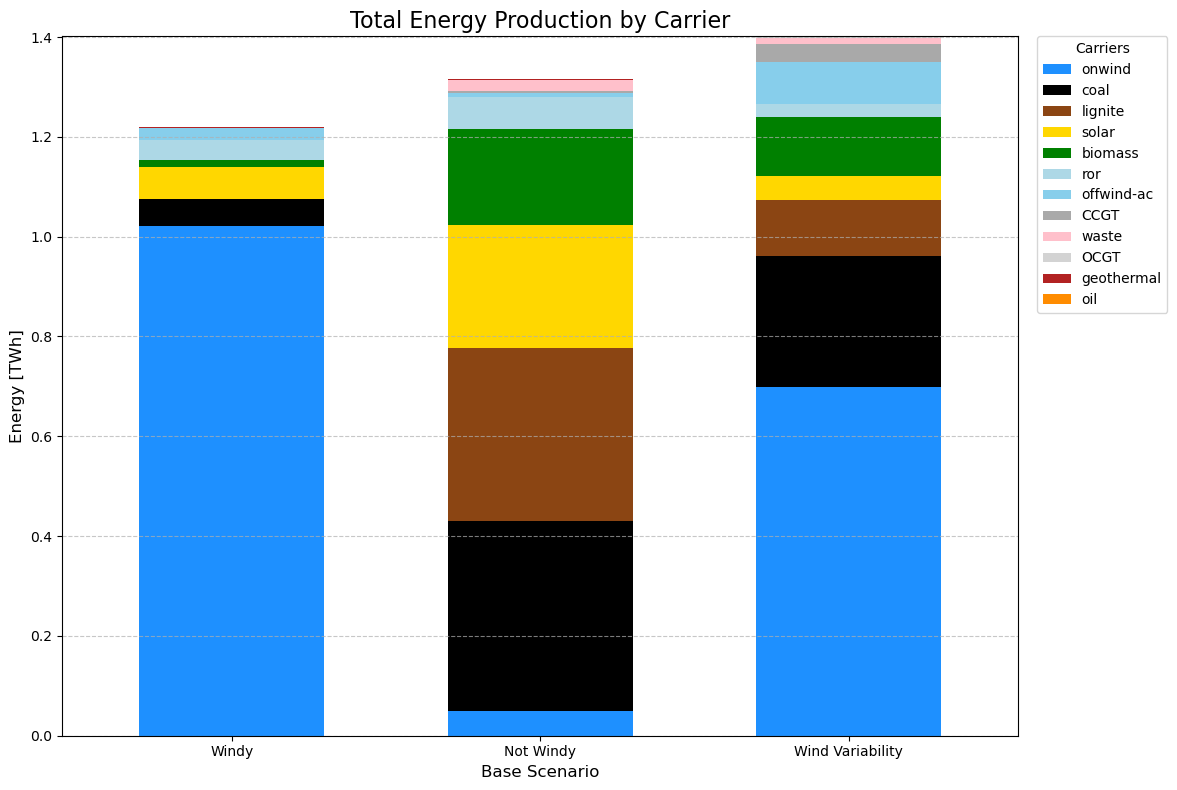

In [66]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]


# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in energy_df.index]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Base Scenario", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()

In [50]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

In [51]:
for n in networks.values():
    print(f"Total CO2 emissions at the {n.name} day: {calculate_emissions(n):.2f} kg CO2")

Total CO2 emissions at the Windy day: 41140.11 kg CO2
Total CO2 emissions at the Not Windy day: 729431.81 kg CO2
Total CO2 emissions at the Wind Variability day: 367574.78 kg CO2
